In [ ]:
%load_ext autoreload
%autoreload 2

In [5]:
from error_analyzer import ErrorAnalyzer
from utils import load_evaluation_data

In [6]:
sample_evaluations = load_evaluation_data("/home/amah/git/ghyadav-azure-sdk/data/allv2MSAIshopping.jsonl")
sample_evaluations[2]

Loaded 100 evaluations from JSONL file


{'thread_id': 'line_2',
 'results': {'IntentResolution': {'intentresolution': 3,
   'intentresolution_result': 'pass',
   'intentresolution_reason': 'User wanted help finding socks. Agent provided a list of options with brief descriptions, but did not clarify where or how to purchase them, leaving the resolution incomplete.',
   'intentresolution_threshold': 3},
  'TaskAdherence': {'taskadherence': 3,
   'taskadherence_result': 'pass',
   'taskadherence_reason': "The assistant attempted to fulfill the user's request by suggesting socks but failed to clarify the ambiguous query and did not use tools, despite the system being silent on tool usage. The response was incomplete and lacked user-specific relevance.",
   'taskadherence_threshold': 3},
  'Relevance': {'relevance': 4,
   'relevance_result': 'pass',
   'relevance_reason': 'The response directly addresses the query by providing specific examples of socks, making it relevant and sufficient. It offers a variety of options but does n

In [7]:
# Initialize the ErrorAnalyzer
analyzer = ErrorAnalyzer()
report = analyzer.generate_enhanced_report(
    evaluations = sample_evaluations,
    fails_only = True,
    num_clusters = 10
)
report

Step 1: Filtering imperfect evaluations...
Step 2: Extracting error patterns...
Step 3: Generating short error names...
Error generating error names for batch 1: Error code: 404 - {'error': {'code': 'DeploymentNotFound', 'message': 'The API deployment for this resource does not exist. If you created the deployment within the last 5 minutes, please wait a moment and try again.'}}
Error generating error names for batch 2: Error code: 404 - {'error': {'code': 'DeploymentNotFound', 'message': 'The API deployment for this resource does not exist. If you created the deployment within the last 5 minutes, please wait a moment and try again.'}}
Error generating error names for batch 1: Error code: 404 - {'error': {'code': 'DeploymentNotFound', 'message': 'The API deployment for this resource does not exist. If you created the deployment within the last 5 minutes, please wait a moment and try again.'}}
Error generating error names for batch 2: Error code: 404 - {'error': {'code': 'DeploymentNotF

{'summary': {'total_evaluations': 100,
  'imperfect_evaluations': 40,
  'total_issues': 87,
  'filter_mode': 'fails_only',
  'unique_error_types': 87,
  'total_reasons_analyzed': 87},
 'patterns': {'evaluation_types': defaultdict(int,
              {'IntentResolution': 29, 'TaskAdherence': 33, 'Relevance': 25}),
  'score_distribution': defaultdict(<function error_analyzer.ErrorAnalyzer.extract_error_patterns.<locals>.<lambda>()>,
              {'IntentResolution': defaultdict(int, {2: 18, 1: 11}),
               'TaskAdherence': defaultdict(int, {2: 25, 1: 8}),
               'Relevance': defaultdict(int, {2: 15, 1: 10})}),
  'reasons': defaultdict(list,
              {'IntentResolution': ['User wanted to know when the Condroi pants in size 48 would be available. The agent failed to provide any specific information or actionable steps to resolve the query, offering only a vague suggestion to check FAQs.',
                "User wanted a return ticket, likely for travel. Agent misunderst

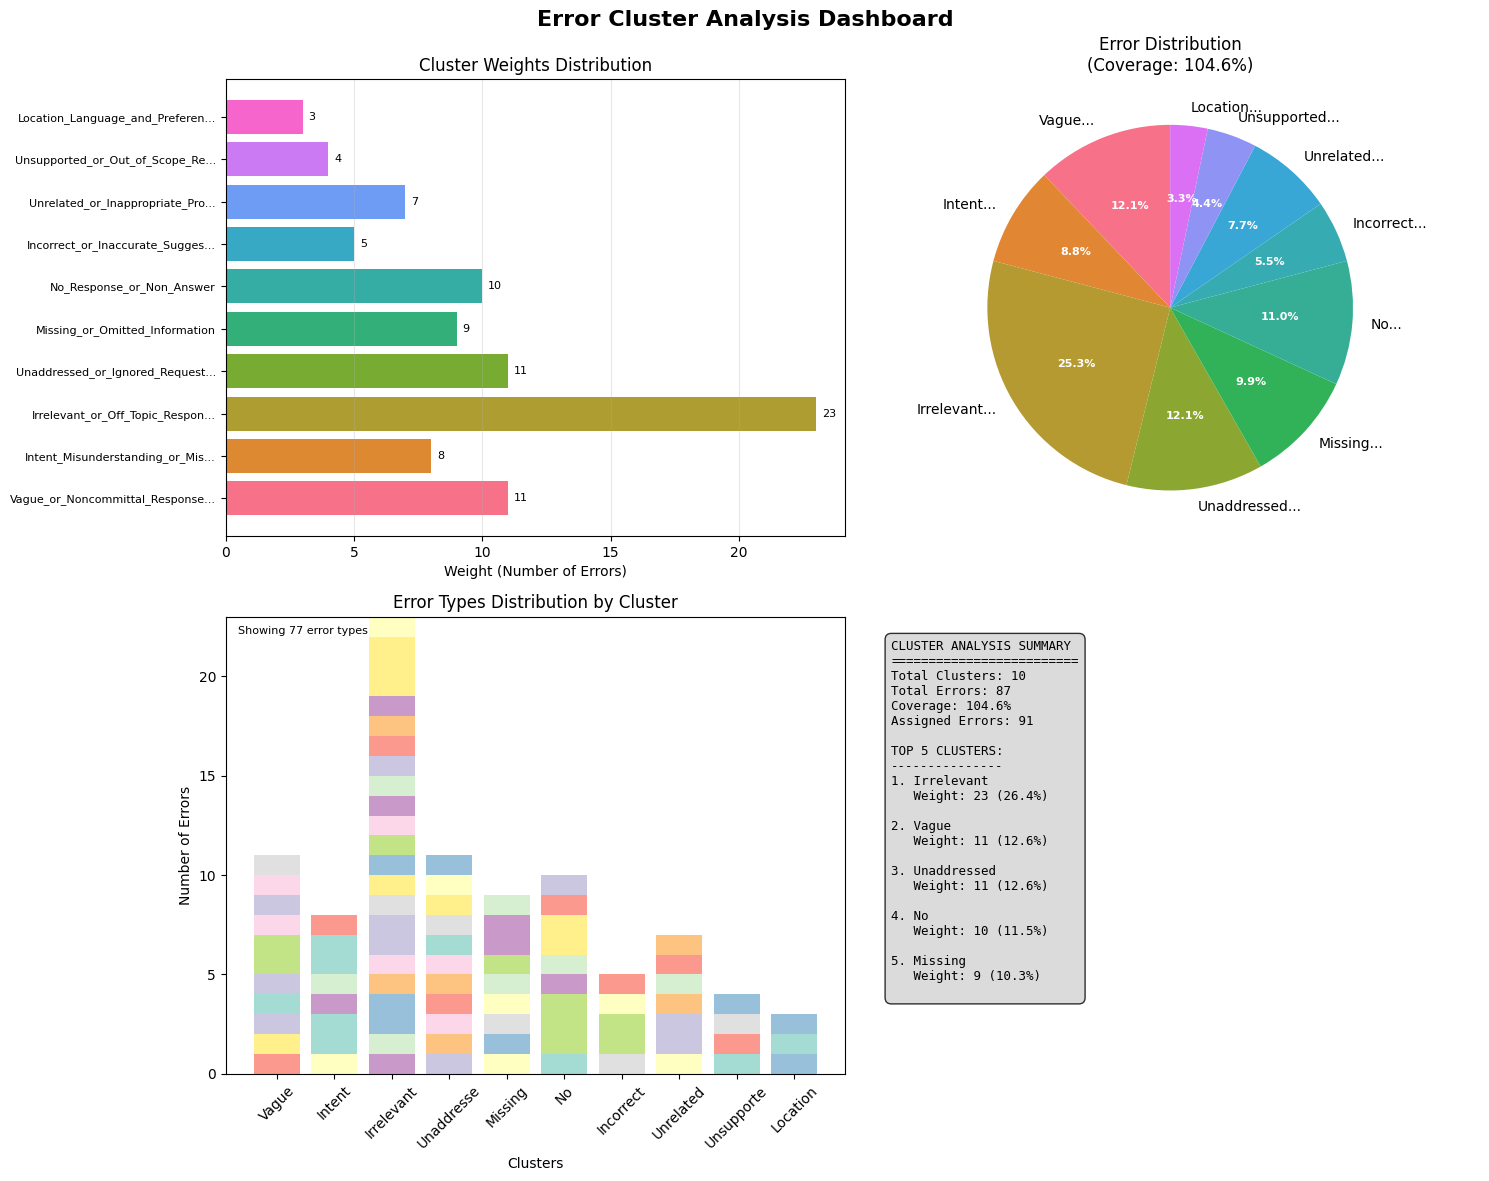

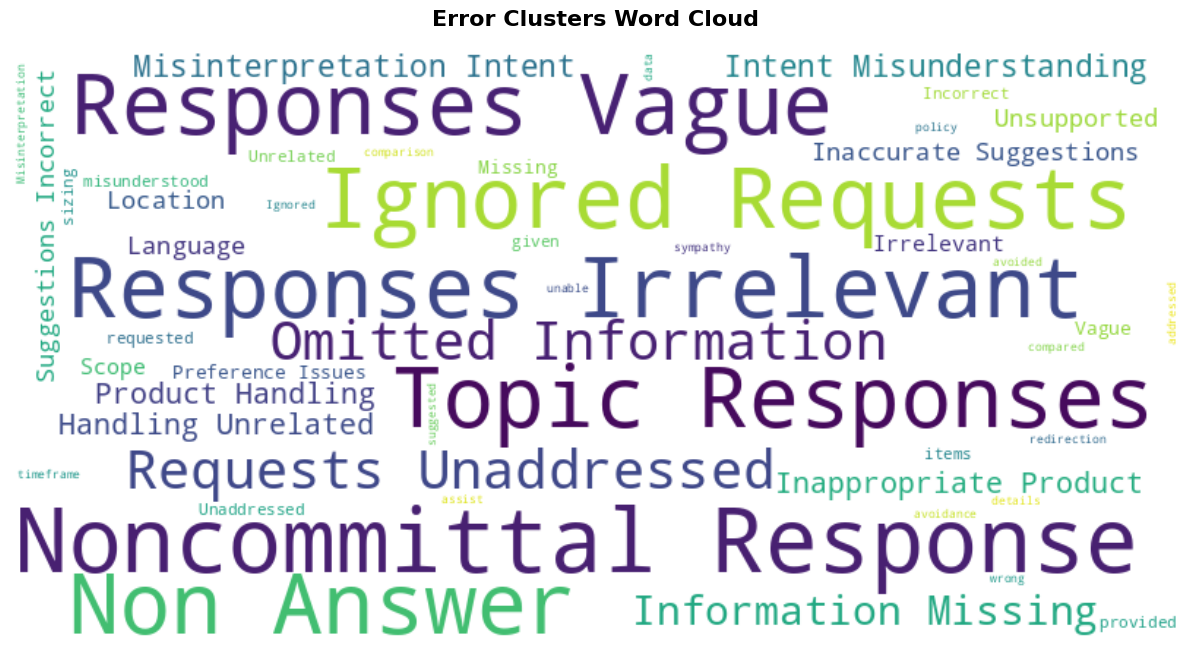

In [10]:
analyzer.visualize_cluster_results(
    cluster_results = report["error_clusters"]
)

# Ste-by-step Run for better understanding of the Process

In [15]:
# Initialize the ErrorAnalyzer
analyzer = ErrorAnalyzer()
analyzer.deployment_name

'gpt-4'

In [9]:
imperfect_evals = analyzer.filter_imperfect_evaluations(sample_evaluations, fails_only=True)
imperfect_evals

[{'thread_id': 'line_0',
  'results': {'IntentResolution': {'intentresolution': 2,
    'intentresolution_result': 'fail',
    'intentresolution_reason': 'User wanted to know when the Condroi pants in size 48 would be available. The agent failed to provide any specific information or actionable steps to resolve the query, offering only a vague suggestion to check FAQs.',
    'intentresolution_threshold': 3},
   'TaskAdherence': {'taskadherence': 2,
    'taskadherence_result': 'fail',
    'taskadherence_reason': 'The assistant failed to provide specific information about the availability of the requested product and did not attempt to use tools or resources to address the query. The response was generic and unhelpful.',
    'taskadherence_threshold': 3},
   'Relevance': {'relevance': 2,
    'relevance_result': 'fail',
    'relevance_reason': 'The response acknowledges the query but fails to provide specific or useful information about the availability of the requested product. It redirec

In [10]:
print("Step 2: Extracting error patterns...")
patterns = analyzer.extract_error_patterns(imperfect_evals)

Step 2: Extracting error patterns...


In [11]:
print("Step 3: Generating short error names...")
all_reasons = []
reason_to_eval_type = {}

for eval_type, reasons in patterns['reasons'].items():
    for reason in reasons:
        all_reasons.append(reason)
        reason_to_eval_type[reason] = eval_type
        

Step 3: Generating short error names...


In [13]:
analyzer.deployment_name

'gpt-4'

In [12]:
error_names = analyzer.generate_error_names(all_reasons)
error_names

Error generating error names for batch 1: Error code: 404 - {'error': {'code': 'DeploymentNotFound', 'message': 'The API deployment for this resource does not exist. If you created the deployment within the last 5 minutes, please wait a moment and try again.'}}
Error generating error names for batch 2: Error code: 404 - {'error': {'code': 'DeploymentNotFound', 'message': 'The API deployment for this resource does not exist. If you created the deployment within the last 5 minutes, please wait a moment and try again.'}}
Error generating error names for batch 3: Error code: 404 - {'error': {'code': 'DeploymentNotFound', 'message': 'The API deployment for this resource does not exist. If you created the deployment within the last 5 minutes, please wait a moment and try again.'}}
Error generating error names for batch 4: Error code: 404 - {'error': {'code': 'DeploymentNotFound', 'message': 'The API deployment for this resource does not exist. If you created the deployment within the last 5 

['Error_1',
 'Error_2',
 'Error_3',
 'Error_4',
 'Error_5',
 'Error_6',
 'Error_7',
 'Error_8',
 'Error_9',
 'Error_10',
 'Error_11',
 'Error_12',
 'Error_13',
 'Error_14',
 'Error_15',
 'Error_16',
 'Error_17',
 'Error_18',
 'Error_19',
 'Error_20',
 'Error_21',
 'Error_22',
 'Error_23',
 'Error_24',
 'Error_25',
 'Error_26',
 'Error_27',
 'Error_28',
 'Error_29',
 'Error_30',
 'Error_31',
 'Error_32',
 'Error_33',
 'Error_34',
 'Error_35',
 'Error_36',
 'Error_37',
 'Error_38',
 'Error_39',
 'Error_40',
 'Error_41',
 'Error_42',
 'Error_43',
 'Error_44',
 'Error_45',
 'Error_46',
 'Error_47',
 'Error_48',
 'Error_49',
 'Error_50',
 'Error_51',
 'Error_52',
 'Error_53',
 'Error_54',
 'Error_55',
 'Error_56',
 'Error_57',
 'Error_58',
 'Error_59',
 'Error_60',
 'Error_61',
 'Error_62',
 'Error_63',
 'Error_64',
 'Error_65',
 'Error_66',
 'Error_67',
 'Error_68',
 'Error_69',
 'Error_70',
 'Error_71',
 'Error_72',
 'Error_73',
 'Error_74',
 'Error_75',
 'Error_76',
 'Error_77',
 'Error_

In [16]:
print("Step 4: Clustering error names...")
cluster_results = analyzer.cluster_error_names(error_names, 10)

Step 4: Clustering error names...


In [19]:
{k: v["weight"] for k, v in cluster_results['clusters'].items()}

{'Irrelevant or Off-Topic Responses': 21,
 'Intent Misunderstood or Misinterpreted': 9,
 'Intent Not Addressed or Ignored': 11,
 'Vague, Generic, or Noncommittal Responses': 11,
 'No Response or Incomplete Response': 8,
 'Missing or Omitted Information': 8,
 'Incorrect or Mismatched Suggestions': 7,
 'Refusal, Dismissal, or Avoidance': 5,
 'Unaddressed User Preferences or Context': 3,
 'Unresolved or Unfulfilled Requests': 2}

Creating cluster visualization...


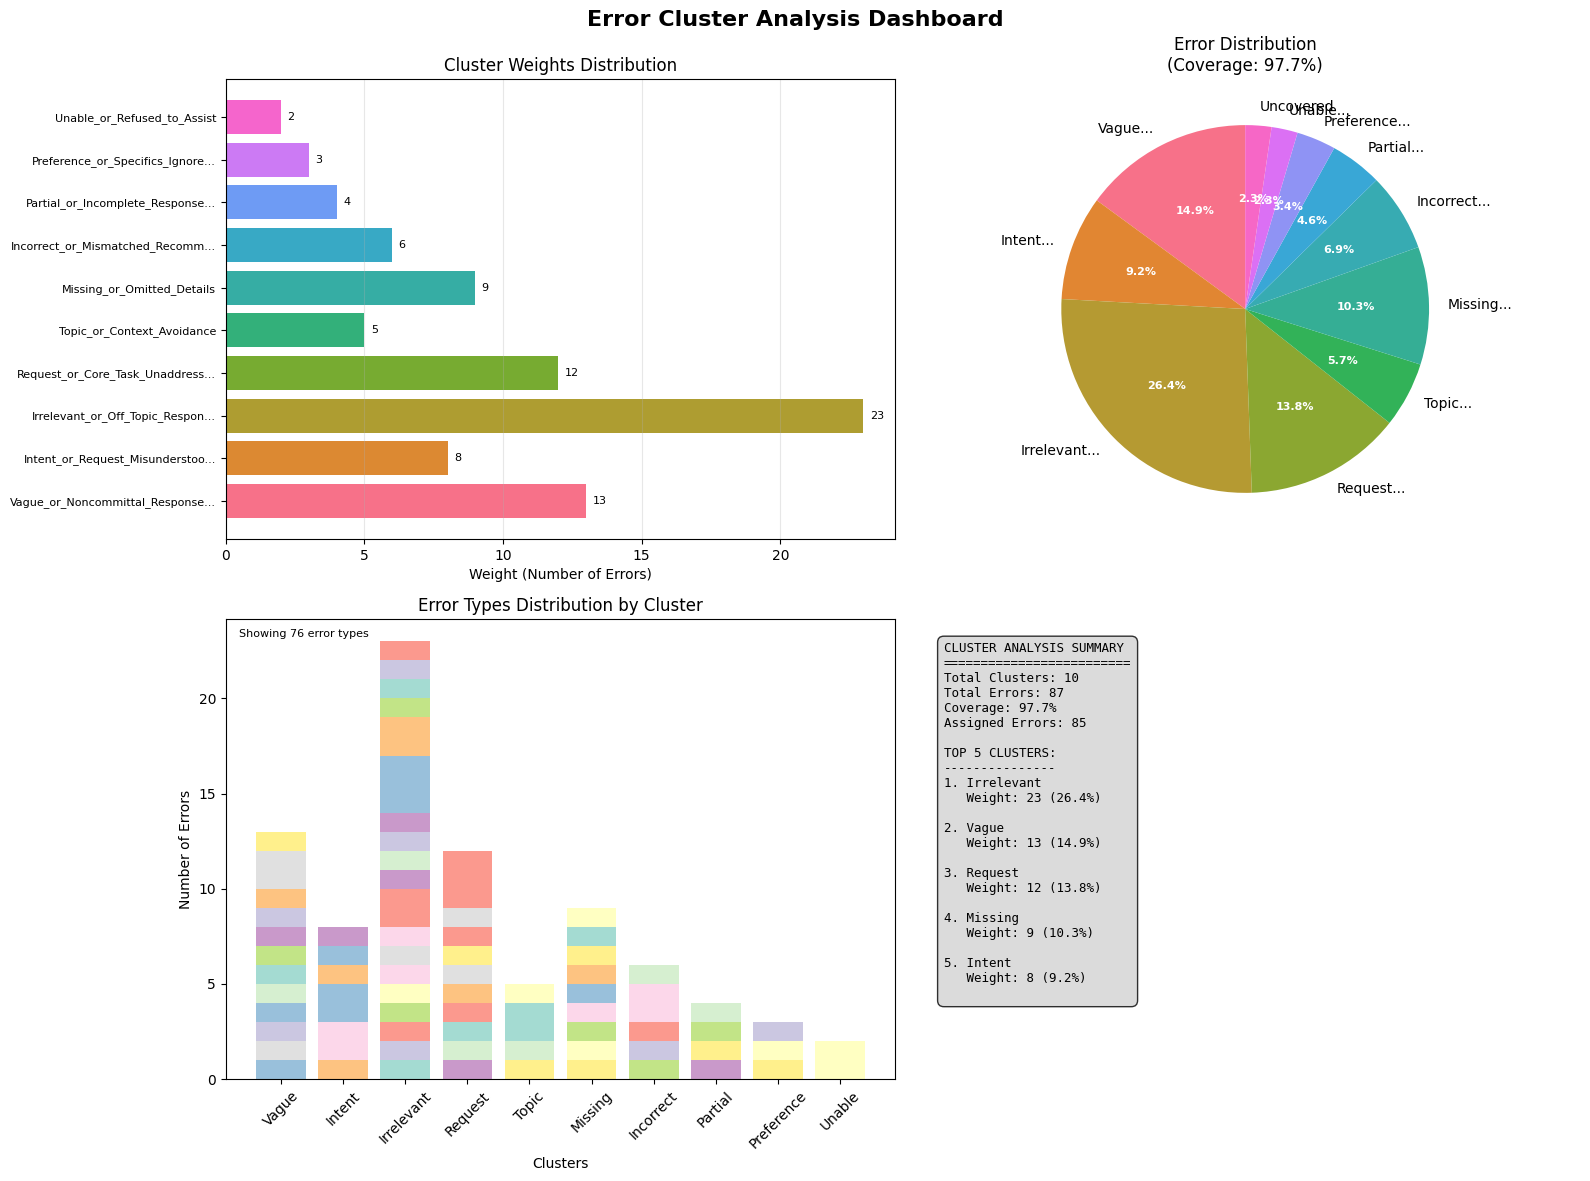

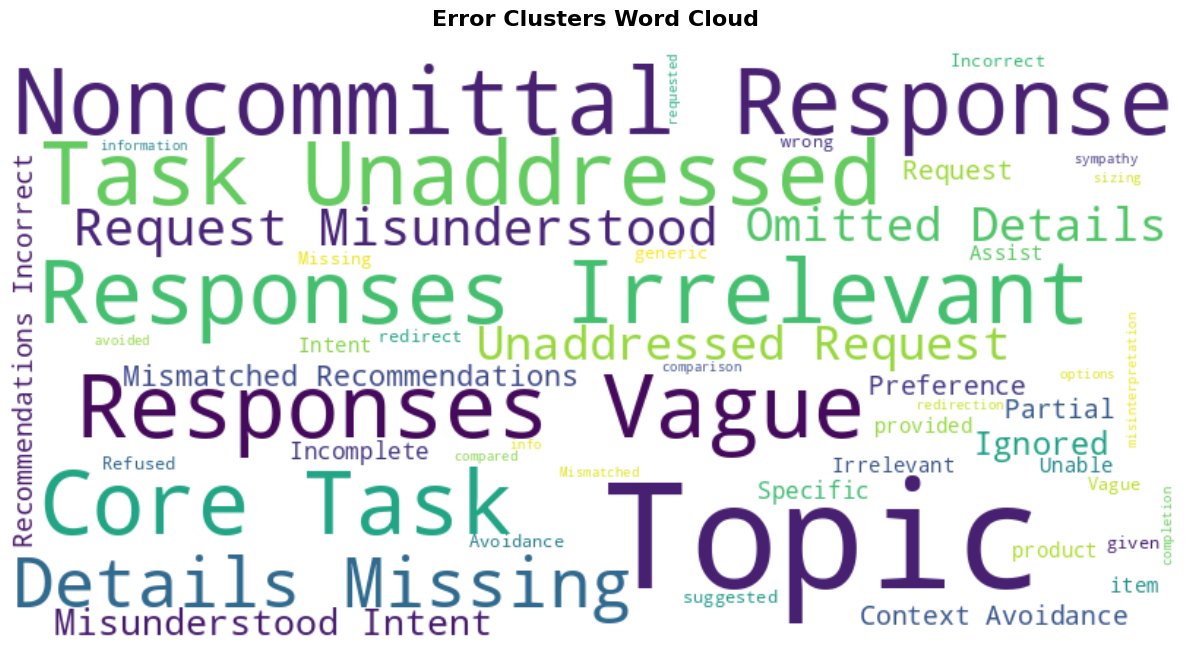

In [19]:
# Install required packages if not already installed
# !pip install matplotlib seaborn wordcloud

# Visualize the cluster results
print("Creating cluster visualization...")
analyzer.visualize_cluster_results(cluster_results, figsize=(16, 12))

# You can also save the visualization
# analyzer.visualize_cluster_results(cluster_results, figsize=(16, 12), save_path="cluster_analysis.png")

# Error Analysis Tool Documentation

## Overview
This notebook provides a comprehensive error analysis tool for evaluation data. It can filter imperfect evaluations and analyze patterns using both statistical methods and LLM-powered insights, with rich visualization capabilities.

## Key Features

### 1. Flexible Filtering
- **`fails_only=True`**: Only include evaluations where `{evaluation_name}_result` is 'fail'
- **`fails_only=False`**: Include all evaluations where the score is not perfect (< 5.0)

### 2. Pattern Analysis
- Frequency analysis of evaluation types with issues
- Score distribution analysis
- Reason extraction and categorization

### 3. LLM-Powered Insights
- Automated summarization of common issues
- Pattern recognition in error reasons
- Recommendations for improvement
- Error name generation and clustering

### 4. Rich Visualizations
- Cluster weight distribution charts
- Error distribution pie charts
- Error type breakdowns by cluster
- Word clouds of error patterns
- Statistical summary tables

## Usage

### Basic Usage
```python
# Initialize analyzer
analyzer = ErrorAnalyzer()

# Generate report
report = analyzer.generate_report(
    evaluations=your_evaluation_list,
    fails_only=False,  # or True for failures only
    use_llm_analysis=True  # requires OpenAI setup
)

# Display results
display_report(report)
```

### Enhanced Analysis with Clustering
```python
# Generate enhanced report with clustering
enhanced_report = analyzer.generate_enhanced_report(
    evaluations=your_evaluation_list,
    fails_only=False,
    use_llm_analysis=True,
    num_clusters=8
)

# Display enhanced results
display_enhanced_report(enhanced_report)

# Visualize cluster results
analyzer.visualize_cluster_results(enhanced_report['error_clusters'])
```

### Data Structure Expected
The tool expects a list of dictionaries with this structure:
```python
[
    {
        'thread_id': 'thread_xyz',
        'results': {
            'EvaluationType1': {
                'evaluationtype1': 3.0,  # score
                'evaluationtype1_result': 'pass',  # or 'fail'
                'evaluationtype1_reason': 'Detailed reason...'
            },
            'EvaluationType2': {
                # similar structure
            }
        }
    }
]
```

### Environment Setup
For LLM analysis, set these environment variables in a `.env` file:
- `AZURE_OPENAI_API_KEY`
- `AZURE_OPENAI_ENDPOINT` 
- `AZURE_OPENAI_API_VERSION`
- `AZURE_OPENAI_DEPLOYMENT_NAME` (optional)

For visualizations, install required packages:
```bash
pip install matplotlib seaborn wordcloud
```

## Report Structure
The generated report includes:
- **Summary**: Overall statistics and issue rates
- **Patterns**: Detailed frequency and score distributions
- **Error Clusters**: Grouped similar errors with weights
- **LLM Analysis**: AI-generated insights and recommendations
- **Visualizations**: Charts, graphs, and word clouds
- **Raw Data**: Filtered evaluation data for further analysis

## Visualization Features
- **Cluster Weight Distribution**: Horizontal bar charts showing error frequency
- **Error Distribution**: Pie charts showing proportional breakdown
- **Error Types by Cluster**: Stacked bars showing composition
- **Statistical Summaries**: Tables with key metrics
- **Word Clouds**: Visual representation of error patterns
- **Export Options**: Save visualizations as PNG files